In [1]:
import yfinance as yf
import datetime
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import acf

import random

from tqdm import tqdm

/Users/hiroku007/miniforge3/envs/trailstone_assessment/lib/python3.8/site-packages/yfinance/base.py:48: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  _empty_series = pd.Series()


In [8]:
vix = yf.Ticker('VXX')


In [16]:
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(60)
vix_hist = vix.history(interval = '2m', start = start_date ,end=end_date)
vix_hist = vix_hist.reset_index()
print(vix_hist)

                      Datetime     Open     High      Low    Close  Volume  \
0    2024-02-15 09:30:00-05:00  14.4000  14.4000  14.3200  14.3400  293748   
1    2024-02-15 09:32:00-05:00  14.3400  14.3400  14.3200  14.3350   72680   
2    2024-02-15 09:34:00-05:00  14.3400  14.3900  14.3301  14.3750   58389   
3    2024-02-15 09:36:00-05:00  14.3800  14.3950  14.3712  14.3714   34057   
4    2024-02-15 09:38:00-05:00  14.3799  14.3799  14.3311  14.3400   46209   
...                        ...      ...      ...      ...      ...     ...   
6803 2024-04-05 15:50:00-04:00  14.2400  14.2500  14.1950  14.2000  188649   
6804 2024-04-05 15:52:00-04:00  14.2000  14.2200  14.1800  14.1900  123941   
6805 2024-04-05 15:54:00-04:00  14.1890  14.1900  14.1500  14.1700  224587   
6806 2024-04-05 15:56:00-04:00  14.1800  14.2050  14.1800  14.2000  181974   
6807 2024-04-05 15:58:00-04:00  14.2000  14.2800  14.1950  14.2800  680618   

      Dividends  Stock Splits  Capital Gains  
0           0.0 

In [17]:
vix_hist.columns

Index(['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Capital Gains'],
      dtype='object')

In [18]:
vix_hist['Date'] = vix_hist.apply(lambda row: row['Datetime'].date(), axis=1)
vix_hist['Time'] = vix_hist.apply(lambda row: row['Datetime'].time(), axis=1)


vix_hist['logClose'] = np.log(vix_hist['Close'])
vix_hist['logOpen'] = np.log(vix_hist['Open'])

vix_hist_date = vix_hist.groupby('Date')
log_returns = vix_hist_date.apply(lambda row: row['logClose']-row['logOpen'])

In [34]:
same_outcome = 0
for (index, df) in vix_hist_date:
    df['logReturn'] = df['logClose'] - df['logOpen']
    same_outcome += np.nansum(np.sign(df['logReturn'].values) * np.sign(df['logReturn'].shift(1).values))

-48.0

(array([2887.,    0.,    0.,    0.,    0.,  961.,    0.,    0.,    0.,
        2960.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

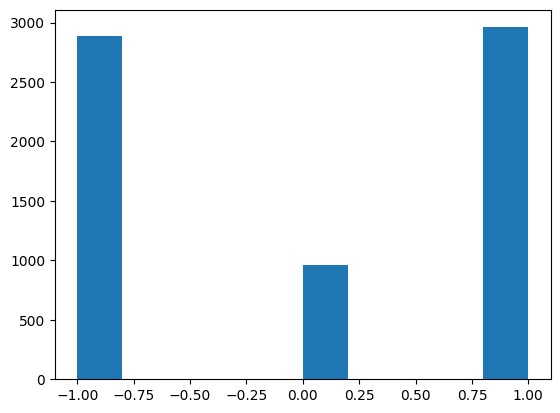

In [36]:
plt.hist(np.sign(log_returns))